In [1]:
%cd ..

/home/hsc/Projects/personal/disertation


In [2]:
import torch

In [3]:
CUDA0 = torch.device("cuda:0")

In [4]:
local_model_path = "checkpoints/"
local_model_directory = (
    "checkpoints/MASt3R_ViTLarge_BaseDecoder_512_catmlpdpt_metric.pth"
)
retrival_model_dir = "checkpoints/MASt3R_ViTLarge_BaseDecoder_512_catmlpdpt_metric_retrieval_trainingfree.pth"

In [5]:
scene_graph: str = "retrieval-20-40"

In [6]:
from mts.pipeline.step.pair.mast3r import Mast3rParer
from mts.pipeline.step.match.mast3r import Mast3rMatchPipelineStep


mast3r_parer = Mast3rParer.from_checkpoints(local_model_directory, retrival_model_dir, scene_graph)
mast3r_matching_step = Mast3rMatchPipelineStep.from_checkpoint(local_model_directory)

Warning, cannot find cuda-compiled version of RoPE2D, using a slow pytorch version instead


/home/hsc/Projects/personal/disertation/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


... loading model from checkpoints/MASt3R_ViTLarge_BaseDecoder_512_catmlpdpt_metric.pth
instantiating : AsymmetricMASt3R(enc_depth=24, dec_depth=12, enc_embed_dim=1024, dec_embed_dim=768, enc_num_heads=16, dec_num_heads=12, pos_embed='RoPE100',img_size=(512, 512), head_type='catmlp+dpt', output_mode='pts3d+desc24', depth_mode=('exp', -inf, inf), conf_mode=('exp', 1, inf), patch_embed_cls='PatchEmbedDust3R', two_confs=True, desc_conf_mode=('exp', 0, inf), landscape_only=False)
<All keys matched successfully>
Loading retrieval model from checkpoints/MASt3R_ViTLarge_BaseDecoder_512_catmlpdpt_metric_retrieval_trainingfree.pth


/home/hsc/Projects/personal/disertation/.venv/lib/python3.11/site-packages/mast3r/retrieval/processor.py:70: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(

... loading model from checkpoints/MASt3R_ViTLarge_BaseDecoder_512_catmlpdpt_metric.pth
instantiating : AsymmetricMASt3R(enc_depth=24, dec_depth=12, enc_embed_dim=1024, dec_embed_dim=768, enc_num_heads=16, dec_num_heads=12, pos_embed='RoPE100',img_size=(512, 512), head_type='catmlp+dpt', output_mode='pts3d+desc24', depth_mode=('exp', -inf, inf), conf_mode=('exp', 1, inf), patch_embed_cls='PatchEmbedDust3R', two_confs=True, desc_conf_mode=('exp', 0, inf), landscape_only=False)
<All keys matched successfully>


In [7]:
mast3r_parer.to(CUDA0)

In [8]:
from app.imc2025.prediction import load_from_train


samples = load_from_train("./data")

In [9]:
from app.imc2025.pipeline import create_repository


image_repository = create_repository("ET")

for prediction in samples["ETs"]:
    image_repository.add_image(prediction.image_filepath)

In [10]:
mast3r_parer.run(image_repository=image_repository)

Found 22 images


100%|██████████| 22/22 [00:08<00:00,  2.71it/s]


In [11]:
mast3r_parer.to(device=torch.device("cpu"))

In [12]:
mast3r_matching_step.to(device=CUDA0)

Mast3rMatchPipelineStep(
  (mast3r_model): AsymmetricMASt3R(
    (patch_embed): PatchEmbedDust3R(
      (proj): Conv2d(3, 1024, kernel_size=(16, 16), stride=(16, 16))
      (norm): Identity()
    )
    (mask_generator): RandomMask()
    (rope): RoPE2D()
    (enc_blocks): ModuleList(
      (0-23): 24 x Block(
        (norm1): LayerNorm((1024,), eps=1e-06, elementwise_affine=True)
        (attn): Attention(
          (qkv): Linear(in_features=1024, out_features=3072, bias=True)
          (attn_drop): Dropout(p=0.0, inplace=False)
          (proj): Linear(in_features=1024, out_features=1024, bias=True)
          (proj_drop): Dropout(p=0.0, inplace=False)
          (rope): RoPE2D()
        )
        (drop_path): Identity()
        (norm2): LayerNorm((1024,), eps=1e-06, elementwise_affine=True)
        (mlp): Mlp(
          (fc1): Linear(in_features=1024, out_features=4096, bias=True)
          (act): GELU(approximate='none')
          (drop1): Dropout(p=0.0, inplace=False)
          (fc2):

In [13]:
mast3r_matching_step.run(image_repository=image_repository)

Computing the matches using Mast3r:   0%|          | 0/462 [00:00<?, ?it/s]/home/hsc/Projects/personal/disertation/.venv/lib/python3.11/site-packages/dust3r/inference.py:44: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=bool(use_amp)):
/home/hsc/Projects/personal/disertation/.venv/lib/python3.11/site-packages/dust3r/model.py:260: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=False):
/home/hsc/Projects/personal/disertation/.venv/lib/python3.11/site-packages/dust3r/inference.py:48: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=False):
Computing the matches using Mast3r: 100%|██████████| 462/462 [05:25<00:00,  1.42it/s]


In [14]:
from mts.pipeline.step.reconstruct.colmap.incremental import ColmapReconstructionStep
from mts.helpers.colmap.options import create_incremental_pipeline_options


colmap_reconstruction_step = ColmapReconstructionStep(
    create_incremental_pipeline_options(
        min_model_size=3,
        max_num_models=25,
    )
)

In [15]:
from app.imc2025.run.from_config import Project


last_project_iteration = Project.from_next_iteration("./iterations")

In [16]:
dataset_dirpath = last_project_iteration.iteration_dirpath / "ET"
dataset_dirpath.mkdir(exist_ok=True)
state = {
    "images_dir": ".",
    "colmap_dirpath": dataset_dirpath,
}

In [17]:
image_repository.get_keypoints(12)

array([[  3.8,  18.8],
       [  3.8,  66.2],
       [  3.8, 417.5],
       ...,
       [355. , 525. ],
       [355. , 535. ],
       [355. , 615. ]], shape=(12738, 2))

In [18]:
colmap_reconstruction_step.run(
    image_repository=image_repository,
    state=state,
)

Add matches:   0%|          | 0/462 [00:00<?, ?it/s](18, 21) is already inserted
(3, 10) is already inserted
(9, 11) is already inserted
(16, 18) is already inserted
(6, 9) is already inserted
(6, 10) is already inserted
(3, 5) is already inserted
(13, 21) is already inserted
(4, 11) is already inserted


(13, 16) is already inserted
(16, 21) is already inserted
(5, 11) is already inserted
(4, 6) is already inserted
(15, 20) is already inserted
(5, 6) is already inserted
(17, 19) is already inserted
(18, 20) is already inserted
(12, 19) is already inserted
(14, 15) is already inserted
(7, 10) is already inserted
(18, 19) is already inserted
(8, 11) is already inserted
(7, 11) is already inserted
(3, 8) is already inserted
(14, 17) is already inserted
(5, 7) is already inserted
(15, 18) is already inserted
(12, 14) is already inserted
(3, 7) is already inserted
(17, 18) is already inserted
(15, 21) is already inserted
(3, 11) is already inserted
(13, 17) is already inserted
(3, 6) is already inserted
(19, 21) is already inserted
(9, 10) is already inserted
(13, 20) is already inserted
(4, 9) is already inserted
(6, 7) is already inserted
(14, 21) is already inserted
(4, 10) is already inserted
(13, 15) is already inserted
(5, 10) is already inserted
(8, 9) is already inserted
(17, 21) is

In [ ]:
from mts.pipeline.repository.inmemeory import ImageRepository
from mts.pipeline.repository.load.colmap import import_from_colmap

image_repository = ImageRepository()

import_from_colmap(image_repository, "iterations/0052/imc2023_haiper/colmap.db")

In [18]:
class CONFIG:
    # DEBUG Settings
    DRY_RUN = False
    DRY_RUN_MAX_IMAGES = 10

    # Pipeline settings
    NUM_CORES = 2
    MAST3R_MIN_PAIR = 15
    MATCH_CONF_TH = 1.001

In [ ]:
import cv2
import numpy as np
from tqdm.auto import tqdm
from collections import defaultdict
import os

from dust3r.utils.image import load_images
from dust3r.inference import inference
from mast3r.fast_nn import fast_reciprocal_NNs, extract_correspondences_nonsym


def match_with_mast3r_and_save(
    index_pairs,
    image_list,
    device,
):
    unique_keypoints = defaultdict(list)
    out_match = defaultdict(dict)

    for idx1, idx2 in tqdm(index_pairs):
        name1, name2 = image_list[idx1], image_list[idx2]
        key1, key2 = os.path.basename(name1), os.path.basename(name2)

        # Only re-run inference for key1 if not in cache
        images = load_images([name1, name2], size=512, verbose=False)
        output = inference(
            [tuple(images)], mast3r_model, device, batch_size=1, verbose=False
        )

        # at this stage, you have the raw dust3r predictions
        view1, pred1 = output["view1"], output["pred1"]
        view2, pred2 = output["view2"], output["pred2"]

        desc1, desc2 = (
            pred1["desc"].squeeze(0).detach(),
            pred2["desc"].squeeze(0).detach(),
        )

        # matches_im0, matches_im1 = fast_reciprocal_NNs(desc1, desc2, subsample_or_initxy1=8, device=device)
        # print(f"get pair for {key1}_{key2}, {len(matches_im0)}")

        conf1, conf2 = (
            pred1["desc_conf"].squeeze(0).detach(),
            pred2["desc_conf"].squeeze(0).detach(),
        )
        corres = extract_correspondences_nonsym(
            desc1, desc2, conf1, conf2, device=device, subsample=8, pixel_tol=5
        )
        score = corres[2]
        mask = score >= CONFIG.MATCH_CONF_TH
        matches_im0 = corres[0][mask].cpu().numpy()
        matches_im1 = corres[1][mask].cpu().numpy()

        # matches_im0 = corres[0].cpu().numpy()
        # matches_im1 = corres[1].cpu().numpy()

        if len(matches_im0) < CONFIG.MAST3R_MIN_PAIR:
            continue

        H0, W0 = view1["true_shape"][0].tolist()
        H1, W1 = view2["true_shape"][0].tolist()

        valid0 = (
            (matches_im0[:, 0] >= 3)
            & (matches_im0[:, 0] < W0 - 3)
            & (matches_im0[:, 1] >= 3)
            & (matches_im0[:, 1] < H0 - 3)
        )
        valid1 = (
            (matches_im1[:, 0] >= 3)
            & (matches_im1[:, 0] < W1 - 3)
            & (matches_im1[:, 1] >= 3)
            & (matches_im1[:, 1] < H1 - 3)
        )
        valid = valid0 & valid1

        matches_im0 = matches_im0[valid]
        matches_im1 = matches_im1[valid]
        if len(matches_im0) < CONFIG.MAST3R_MIN_PAIR:
            continue
        # print("transform_keypoints_to_original begin")
        # print(f"{key1}_{key2}: {len(matches_im0)} matches")
        img0 = cv2.imread(name1)
        img1 = cv2.imread(name2)
        H0, W0 = img0.shape[:2]
        H1, W1 = img1.shape[:2]
        matches_im0_org = transform_keypoints_to_original(matches_im0, (H0, W0))
        matches_im1_org = transform_keypoints_to_original(matches_im1, (H1, W1))

        # matches_im0_org = transform_keypoints_to_original(matches_im0, view1['true_shape'][0].tolist())
        # matches_im1_org = transform_keypoints_to_original(matches_im1, view2['true_shape'][0].tolist())
        # print("transform_keypoints_to_original end")

        unique_keypoints[key1].append(matches_im0_org)
        unique_keypoints[key2].append(matches_im1_org)
        out_match[key1][key2] = np.concatenate(
            [matches_im0_org, matches_im1_org], axis=1
        )

    # print("out of loop")

    keypoints_unified = {}
    keypoints_id_map = {}
    out_match_unified = defaultdict(dict)

    global_keypoints, global_matches = unify_keypoints_and_matches(out_match)
    # print("points and matches unified")
    return global_keypoints, global_matches

In [20]:
images_filepaths = list(image_repository.image_filepaths())
filename_to_idx = {
    image_filepath: idx
    for idx, image_filepath in enumerate(images_filepaths)
}

In [21]:
indexed_pairs = [
    (
        filename_to_idx[st_filepath],
        filename_to_idx[nd_filepath],
    )
    for st_filepath, nd_filepath in sorted_pairs
]

In [23]:
mast3r_model.to(CUDA0)

AsymmetricMASt3R(
  (patch_embed): PatchEmbedDust3R(
    (proj): Conv2d(3, 1024, kernel_size=(16, 16), stride=(16, 16))
    (norm): Identity()
  )
  (mask_generator): RandomMask()
  (rope): RoPE2D()
  (enc_blocks): ModuleList(
    (0-23): 24 x Block(
      (norm1): LayerNorm((1024,), eps=1e-06, elementwise_affine=True)
      (attn): Attention(
        (qkv): Linear(in_features=1024, out_features=3072, bias=True)
        (attn_drop): Dropout(p=0.0, inplace=False)
        (proj): Linear(in_features=1024, out_features=1024, bias=True)
        (proj_drop): Dropout(p=0.0, inplace=False)
        (rope): RoPE2D()
      )
      (drop_path): Identity()
      (norm2): LayerNorm((1024,), eps=1e-06, elementwise_affine=True)
      (mlp): Mlp(
        (fc1): Linear(in_features=1024, out_features=4096, bias=True)
        (act): GELU(approximate='none')
        (drop1): Dropout(p=0.0, inplace=False)
        (fc2): Linear(in_features=4096, out_features=1024, bias=True)
        (drop2): Dropout(p=0.0, i

In [25]:
from pathlib import Path


feature_dir = Path("./testing-master")

In [26]:
feature_dir.mkdir(exist_ok=True)

In [27]:
global_kps, global_matched = match_with_mast3r_and_save(
    indexed_pairs,
    images_filepaths,
    feature_dir,
    mast3r_model,
    CUDA0,
    None,
)

  0%|          | 0/1227 [00:00<?, ?it/s]

/home/hsc/Projects/personal/disertation/.venv/lib/python3.11/site-packages/dust3r/inference.py:44: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=bool(use_amp)):
/home/hsc/Projects/personal/disertation/.venv/lib/python3.11/site-packages/dust3r/model.py:260: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=False):
/home/hsc/Projects/personal/disertation/.venv/lib/python3.11/site-packages/dust3r/inference.py:48: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=False):
100%|██████████| 1227/1227 [20:12<00:00,  1.01it/s]


In [71]:
matches_filenames = list(global_matched)

In [57]:
filename_to_filepath = {
    Path(
        image_filepath,
    ).name: image_filepath
    for image_filepath in images_filepaths
}

In [123]:
st_image_filename, nd_image_filename = matches_filenames[10]

In [124]:
st_image_id = image_repository.get_image_id(filename_to_filepath[st_image_filename])
nd_image_id = image_repository.get_image_id(filename_to_filepath[nd_image_filename])


st_image = image_repository.load_image(st_image_id)
nd_image = image_repository.load_image(nd_image_id)

st_kp, nd_kp = global_kps[st_image_filename], global_kps[nd_image_filename]

matches = global_matched[st_image_filename, nd_image_filename]
st_matches, nd_matches = matches.T

In [125]:
from hloc.utils import viz as img_viz

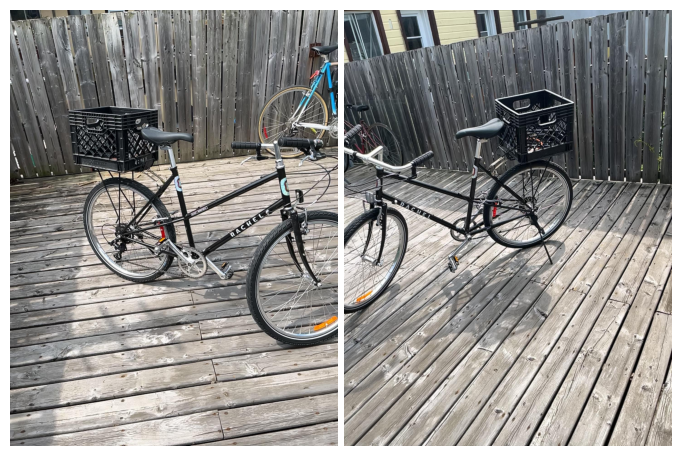

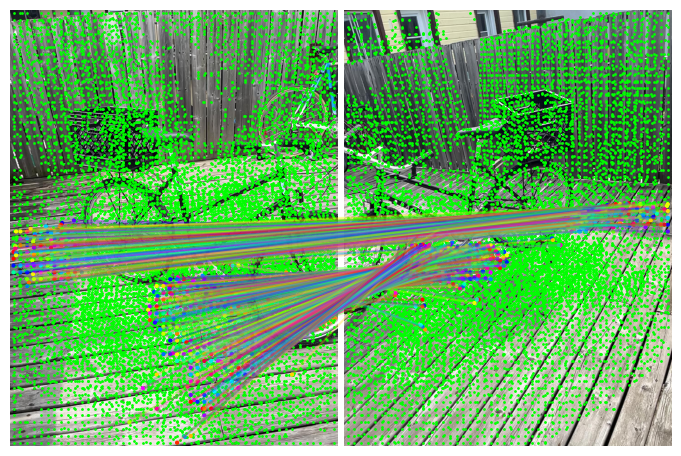

In [126]:
img_viz.plot_images([st_image, nd_image])
img_viz.plot_images([st_image, nd_image])
img_viz.plot_keypoints([st_kp, nd_kp])

img_viz.plot_matches(st_kp[st_matches], nd_kp[nd_matches], a=0.3)